This notebook will test several model to for the recodification cno to ciuo problem

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [35]:
df = pd.read_csv("../data/processed/enes_2019.csv")
df.head()

,nocues,nhog,miembro,f_calib3,region,aglo,t_aglo,estrato_U,cod_U,age,...,v215b,v215bi,v216a,v216b,v216bi,v217a,v217b,v217bi,total_income,ITI_d
0,1.0,1.0,1.0,778.0,3.0,6.0,4.0,164.0,682.0,56,...,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,4500.0,6.0
1,1.0,1.0,2.0,778.0,3.0,6.0,4.0,164.0,682.0,51,...,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,4000.0,5.0
2,1.0,1.0,3.0,778.0,3.0,6.0,4.0,164.0,682.0,31,...,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN
3,1.0,1.0,4.0,778.0,3.0,6.0,4.0,164.0,682.0,31,...,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN
4,2.0,1.0,1.0,485.0,3.0,6.0,4.0,164.0,682.0,21,...,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,6000.0,7.0


Variables per quantity and percentage of nulls, sorted by percentage of nulls

In [36]:
n = df.shape[0]
nulls = df.isnull().sum()
nulls_perc = nulls / n
nulls_df = pd.DataFrame(
	{"variable": df.columns, "nulls": nulls, "nulls_perc": nulls_perc}
)
nulls_df = nulls_df.sort_values("nulls_perc", ascending=False)
print(f"Number of variables: {df.shape[1]}")
print(f"Total number of rows: {n}")
nulls_df.head(20)


Number of variables: 157
Total number of rows: 15556


,variable,nulls,nulls_perc
v127,v127,15556,1.000000
v129,v129,15556,1.000000
v128,v128,15556,1.000000
v147c,v147c,15555,0.999936
v150b_pais,v150b_pais,15544,0.999229
v126,v126,15525,0.998007
v147b,v147b,15522,0.997814
v133,v133,15496,0.996143
v118b,v118b,15487,0.995564
v170,v170,15396,0.989715


Histogram for better understanding

<Axes: xlabel='nulls_perc', ylabel='Count'>

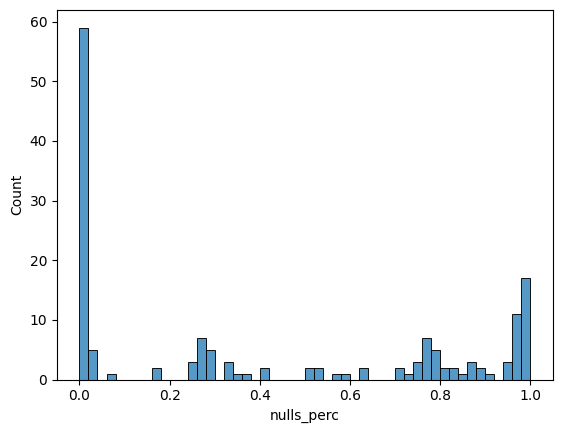

In [37]:
sns.histplot(data=nulls_df, x="nulls_perc", bins=50)

In [61]:
elegible_variables = nulls_df[nulls_df["nulls_perc"] < 0.15]
print(f"Number of elegible variables: {elegible_variables.shape[0]}")
df = df[elegible_variables["variable"]]
print(list(elegible_variables.index))

Number of elegible variables: 65
['v213bi', 'v214bi', 'v116', 'v148', 'v152a', 'CSO', 'v190', 'v114', 'v149a', 'v147a', 'v122', 'v121', 'v163', 'v215a', 'v215bi', 'egp11', 'v217a', 'v217bi', 'v216a', 'v216bi', 't_hogar', 'c_hogar', 'v117', 'v111', 'v118a', 'estado', 'v110', 'sex_id', 'v119', 'cod_U', 'estrato_U', 't_aglo', 'aglo', 'region', 'f_calib3', 'miembro', 'age', 'v135', 'v120', 'v158', 'nhog', 'v186', 'v164', 'v182caes', 'v183ciuo', 'v183cno', 'public_worker', 'v189', 'v191', 'v162', 'v161', 'v157', 'nivel_ed', 'v156', 'v155', 'v154', 'cat_ocup', 'v153', 'v142', 'v141', 'v140', 'v139', 'v171', 'v134a', 'nocues']


In [62]:
varibles_df = pd.read_csv("../data/raw/metadata_base_enespersonas.csv")
varibles_df = varibles_df[varibles_df["Column Title"].isin(elegible_variables.index)]
varibles_df = varibles_df.set_index("Column Title")
print(varibles_df)

             Data Type                                        Description
Column Title                                                             
nocues         Integer                        Housing Identification Code
nhog           Integer                      Household Identification Code
miembro        Integer                         Member Identification Code
f_calib3       Integer                                 Calibration Factor
region         Integer                                             Region
...                ...                                                ...
v215bi         Integer  Income Amount from Retirements or Pensions Las...
v216a          Integer  Perception of Income from Social Pensions, AHU...
v216bi         Integer  Income Amount from Social Pensions, AHU, or Ot...
v217a          Integer              Perception of Other Income Last Month
v217bi         Integer           Other Income Amount Last Month (Imputed)

[62 rows x 2 columns]


variales_df will be used to understand the variables that we have in the dataset and statistics

In [68]:
# distinct values per variable
distinct_values = df.nunique(dropna=False)
varibles_df["distinct_values"] = distinct_values
varibles_df.sort_values("distinct_values", ascending=False).head(20)

,Data Type,Description,distinct_values
Column Title,,,
nocues,Integer,Housing Identification Code,7791
f_calib3,Integer,Calibration Factor,2971
cod_U,Integer,Code of the Primary Unit,983
v213bi,Integer,Net Income Amount in Main Occupation Last Mont...,554
v183cno,Integer,Type of Occupation (National Classifier of Occ...,552
v183ciuo,Integer,Type of Occupation (International Standard Cla...,447
v215bi,Integer,Income Amount from Retirements or Pensions Las...,381
estrato_U,Integer,Stratum of the Primary Unit,268
v217bi,Integer,Other Income Amount Last Month (Imputed),219


<Axes: xlabel='distinct_values', ylabel='Count'>

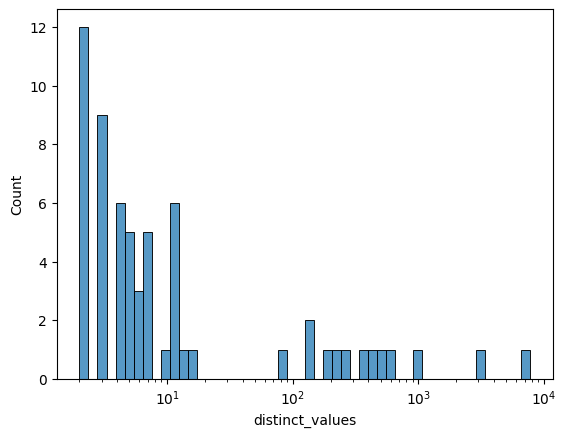

In [70]:
# Histogram of distinct values
sns.histplot(data=varibles_df, x="distinct_values", bins=50, log_scale=True)